# Introduction
- Social media platforms generate enormous volumes of engagement data every day — including likes, comments, shares, impressions, watch time, and follower counts.
- This data provides valuable insights into how users interact with content, what trends emerge across different demographics, and how engagement varies by post type or category.

## Analyzing such datasets helps companies:

- Understand user behavior and preferences.
- Identify trending content and audience interests.
- Measure and improve content performance.
- Support data-driven decision making in marketing and strategy.

- The dataset provided, social_media_engagement_5000.csv, contains 5,000 records of social media posts with detailed engagement metrics and user attributes. Key features include:
- User demographics: user_id, age, gender, country, follower_count, is_verified.
- Post details: post_id, post_type (image, video, text, reel), post_category (fitness, food, travel, etc.), hashtags.
- Engagement metrics: likes, comments, shares, impression_count, watch_time_sec.
- Metadata: date_posted-at, device_type, sentiment.

### The tasks involve:

- Data cleaning → fixing incorrect data types, handling missing values, standardizing categories.
- Transformation → creating new features (e.g., hashtag counts, engagement rate).
- NumPy/Pandas operations → statistical summaries, aggregations, group analysis.
- Exploratory Data Analysis (EDA) → distributions, correlations, trends.
- Visualizations → histograms, boxplots, bar charts, scatter plots.
- Insights generation → identifying what drives engagement and how different factors influence performance.

In [1]:
!pip install seaborn
!pip install matplotlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



In [2]:
# importing csv file
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\social_media_engagement_5000.csv")


df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


### Shape
- When you check the shape of a dataset in pandas, you’re looking at its dimensions:
- A tuple → (rows, columns)
- Example: (5000, 15) means:

In [12]:
print("\nShape:", df.shape)



Shape: (5000, 19)


### df.head()
- Shows the first 5 rows of your DataFrame by default.

In [13]:
print("\nfirst 5 rows:")
display(df.head())



first 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


### df.tail()
- Shows the last 5 rows of your DataFrame by default.

In [14]:
print("\nLast 5 rows:")
display(df.tail())


Last 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


### Common dtype values

- int64 → integers (whole numbers like counts, IDs, etc.)
- float64 → decimals (likes, comments, shares, watch time, etc.)
- object → usually strings/text (names, categories, hashtags, country, sentiment)
- bool → True/False values (like is_verified)
- datetime64[ns] → dates and times (date_posted-at)

In [15]:
print("\nData types:")
display(df.dtypes)



Data types:


user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object

### What df.info() Does

- Index range → shows how many rows (e.g., RangeIndex: 5000 entries, 0 to 4999).
- Column names → lists all columns in the DataFrame.
- Non‑null counts → tells you how many non‑missing values each column has.
- Dtype → the data type of each column (int64, float64, object, bool, datetime64[ns]).
- Memory usage → how much RAM the DataFrame is consuming.


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   str    
 3   country           5000 non-null   str    
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   str    
 6   post_category     5000 non-null   str    
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   str    
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   str    
 16  sentiment         4850 non-null   str    
 17  hashta

In [8]:
import warnings
warnings.filterwarnings('ignore')


In [26]:
# Changing the data type of the date column to datetime.

df["posted_at"] = pd.to_datetime(df["posted_at"])

In [9]:
# changing column name posted_at to date_posted_at.
df = df.rename(columns={"posted_at": "date_posted-at"})
df


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,date_posted-at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


### checking nulls ( likes,comments,shares)

In [28]:
# handling nulls
df[["likes","comments","shares"]] = df[["likes","comments","shares"]].fillna(0).astype(int)
df[["likes","comments","shares"]].isnull().sum()


likes       0
comments    0
shares      0
dtype: int64

In [29]:
# handling null values for column age using fillna(mean)
df["age"] = df["age"].fillna(df["age"].mean()).astype(int)
df["age"].isnull().sum()


np.int64(0)

In [30]:
# checking data type
df["age"].dtype

dtype('int64')

In [51]:
# checking outlier for likes
Q1 = df["likes"].quantile(0.25)   # 25th percentile
Q3 = df["likes"].quantile(0.75)   # 75th percentile
IQR = Q3 - Q1

# Outliers are values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
outliers = df[(df["likes"] < Q1 - 1.5*IQR) | (df["likes"] > Q3 + 1.5*IQR)]
print(outliers)


Empty DataFrame
Columns: [user_id, age, gender, country, post_id, post_type, post_category, likes, comments, shares, watch_time_sec, impression_count, date_posted-at, follower_count, is_verified, device_type, sentiment, hashtags, engagement_rate, hashtag_count]
Index: []


In [32]:
# finding mode for categorical column to fill null values
df['sentiment'].mode()

0    positive
Name: sentiment, dtype: str

In [33]:
# Handling null value using fillna -for column-sentiment
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])
df["sentiment"].isnull().sum()

np.int64(0)

In [34]:
df["sentiment"].isnull().sum()

np.int64(0)

In [35]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df["gender"].isnull().sum()

np.int64(0)

In [36]:
# after handling the nulls
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  date_posted-at    5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 non-null   b

In [37]:
df.duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [3]:
df.duplicated().sum()


np.int64(0)

### Explanation:

- duplicated() → marks rows that are exact duplicates.
- drop_duplicates() → removes them.
- Always check before and after to confirm.

In [4]:
# Check duplicates
print("Duplicate rows before removal:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Confirm removal
print("Duplicate rows after removal:", df.duplicated().sum())


Duplicate rows before removal: 0
Duplicate rows after removal: 0


In [40]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'date_posted-at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='str')

### Convert numeric columns:

- pd.to_numeric() → converts text numbers into integers/floats.
- errors='coerce' → replaces invalid values with NaN (so you can handle them later).
- pd.to_datetime() → ensures date columns are proper datetime objects.

In [49]:
# Convert numeric columns stored as object
df['likes'] = pd.to_numeric(df['likes'], errors='coerce')
df['comments'] = pd.to_numeric(df['comments'], errors='coerce')
df['shares'] = pd.to_numeric(df['shares'], errors='coerce')

# Convert date column to datetime
df['date_posted-at'] = pd.to_datetime(df['date_posted-at'], errors='coerce')
# Check again
print(df.dtypes)


user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
date_posted-at      datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
hashtag_count                int64
dtype: object


### Standardize Categories (e.g., Gender Labels)
- Categorical values often have inconsistent spelling or casing.
- str.strip() → removes spaces.
- str.lower() → makes everything lowercase for consistency.
- replace() → maps variations to standard labels.

In [45]:
# Standardize gender labels
df['gender'] = df['gender'].str.strip().str.lower()

# Replace variations with standard labels
df['gender'] = df['gender'].replace({
    'male':'Male',
    'm':'Male',
    'female':'Female',
    'f':'Female'
})

print(df['gender'].value_counts())


gender
Male      1699
other     1581
Female    1570
Name: count, dtype: int64


In [43]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'date_posted-at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='str')

### Correct Unrealistic Values
- Engagement metrics should never be negative.
- If values are unrealistically high (outliers), replace them with median values to keep analysis balanced.

In [46]:
# Remove negative values
df = df[(df['likes'] >= 0) & (df['comments'] >= 0) & (df['shares'] >= 0)]

# Cap unrealistic values (convert to float first)
df[['likes', 'comments', 'shares']] = df[['likes', 'comments', 'shares']].astype(float)

df.loc[df['likes'] > 1_000_000, 'likes'] = df['likes'].median()
df.loc[df['comments'] > 500_000, 'comments'] = df['comments'].median()
df.loc[df['shares'] > 500_000, 'shares'] = df['shares'].median()

# Display summary stats properly
print("\nSummary stats:")
display(df[['likes', 'comments', 'shares']].describe().round(2))



Summary stats:


,likes,comments,shares
count,4565.00,4565.00,4565.00
mean,10089.13,1500.38,1004.36
std,5783.45,871.94,580.25
min,10.00,0.00,0.00
25%,5043.00,751.00,498.00
50%,10057.00,1497.00,1016.00
75%,15113.00,2259.00,1506.00
max,19998.00,2999.00,1999.00


## Feature cleaning
- str(x).split('#') splits text by #.
- Subtract 1 because splitting adds an empty string before the first hashtag.

In [7]:
# Count hashtags in each post
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split('#')) - 1)


# Check results
print(df[['hashtags','hashtag_count']].head())



                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


###  cleaning sentiment lables
- strip() removes spaces.
- lower() makes everything lowercase.
- replace() maps variations to clean labels.

In [46]:
# Standardize sentiment labels
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# Replace variations with standard labels
df['sentiment'] = df['sentiment'].replace({
    'positive':'Positive',
    'pos':'Positive',
    'negative':'Negative',
    'neg':'Negative',
    'neutral':'Neutral',
    'neu':'Neutral'
})

# Check distribution
print(df['sentiment'].value_counts())


sentiment
Positive    2513
Neutral     1527
Negative     960
Name: count, dtype: int64


### Verify Feature Cleaning

- Hashtag count → numeric feature for engagement analysis.
- Sentiment labels → standardized categories for sentiment analysis.

In [8]:
print(df[['hashtag_count','sentiment']].head())
print("="*40)
print(df['sentiment'].unique())


   hashtag_count sentiment
0              3  negative
1              1  negative
2              1  positive
3              3  negative
4              1  negative
<StringArray>
['negative', 'positive', 'neutral', nan]
Length: 4, dtype: str


In [48]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'date_posted-at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='str')

## Data Exploration:

- head(), tail(), shape, columns → quick look at dataset structure.
- info(), dtypes → check column types and missing values.
- describe() → summary stats (mean, std, min, max).
- value_counts(), unique(), nunique() → categorical distributions.
- corr() → correlation matrix for numeric fields.
- groupby() → aggregated insights (likes by post type, impressions by country, engagement by sentiment).

In [9]:
# 1. View dataset structure
print("First 5 rows:\n", df.head())
print("="*100)
print("\nLast 5 rows:\n", df.tail())
print("="*100)
print("\nShape of dataset:", df.shape)
print("="*100)
print("\nColumn names:", df.columns.tolist())

First 5 rows:
    user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count   posted_at  \
0     354.0  1157.0            5726             44650  17-12-2022   
1    2606.0  1807.0            5947             80216  02-06-2023   
2     344.0   955.0            6946             44858  07-05-2023   
3    1083.0  1049.0             229             70455  12-02-2023   
4    2735.0  1300.0            4798              6019  23-05-2023   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734     

In [10]:
# 2. Check data types and info
print("\nData Types:\n", df.dtypes)
print("="*60)



Data Types:
 user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
hashtag_count         int64
dtype: object


In [51]:
# 3. Summary statistics for numeric columns
print("\nSummary Statistics:\n", df.describe().round(2))


Summary Statistics:
         user_id      age    post_id     likes  comments   shares  \
count   5000.00  5000.00    5000.00   5000.00   5000.00  5000.00   
mean   54561.89    38.44  548042.91   9803.83   1457.13   972.55   
min    10055.00    13.00  100068.00      0.00      0.00     0.00   
25%    32309.50    26.00  322543.50   4625.75    675.00   447.75   
50%    54374.50    38.00  548077.50   9776.00   1454.50   981.50   
75%    77180.50    51.00  771574.50  14959.00   2235.25  1483.00   
max    99963.00    64.00  999455.00  19998.00   2999.00  1999.00   
std    26090.37    14.69  260646.96   5957.30    893.92   595.93   

       watch_time_sec  impression_count              date_posted-at  \
count         5000.00           5000.00                        5000   
mean          4014.50          50013.73  2022-12-28 13:21:30.240000   
min              0.00            105.00         2022-01-01 00:00:00   
25%           2017.75          24988.25         2022-07-03 18:00:00   
50%       

In [11]:
# 4. Analyze categorical distributions
print("\nGender distribution:\n", df['gender'].value_counts())
print("="*40)
print("\nUnique countries:", df['country'].nunique())
print("="*40)
print("\nTop 10 countries:\n", df['country'].value_counts().head(10))
print("="*40)

print("\nUnique post types:", df['post_type'].unique())
print("="*40)
print("\nPost type counts:\n", df['post_type'].value_counts())


Gender distribution:
 gender
Male      1699
Other     1581
Female    1570
Name: count, dtype: int64

Unique countries: 10

Top 10 countries:
 country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

Unique post types: <StringArray>
['image', 'reel', 'text', 'video']
Length: 4, dtype: str

Post type counts:
 post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64


### Correlation Means

- Correlation measures the strength and direction of the relationship between two variables.
- Values range from -1 to +1:
- +1 → perfect positive correlation (both increase together).
- -1 → perfect negative correlation (one increases while the other decreases).
- 0 → no linear relationship.


### Example Insights
- If likes and comments have a correlation of 0.85, it means posts with more likes usually also get more comments.
- If watch_time_sec and shares have a weak correlation (e.g., 0.12), it means watch time doesn’t strongly influence sharing behavior.

In [12]:
# 5. Correlation matrix for numeric fields
print("\nCorrelation Matrix:\n", df.corr(numeric_only=True).round(2))



Correlation Matrix:
                   user_id   age  post_id  likes  comments  shares  \
user_id              1.00 -0.01     0.02   0.03     -0.03    0.01   
age                 -0.01  1.00    -0.01  -0.04     -0.01    0.01   
post_id              0.02 -0.01     1.00   0.01     -0.01    0.00   
likes                0.03 -0.04     0.01   1.00     -0.02    0.00   
comments            -0.03 -0.01    -0.01  -0.02      1.00    0.01   
shares               0.01  0.01     0.00   0.00      0.01    1.00   
watch_time_sec      -0.02  0.01     0.02   0.01     -0.02    0.01   
impression_count     0.02  0.01    -0.01   0.01     -0.01   -0.01   
follower_count       0.01 -0.03    -0.00  -0.02     -0.01   -0.01   
is_verified          0.00 -0.00     0.03  -0.02     -0.01    0.01   
engagement_rate     -0.00  0.01     0.01   0.09      0.00    0.02   
hashtag_count       -0.01  0.01     0.01  -0.00     -0.02    0.01   

                  watch_time_sec  impression_count  follower_count  \
user_id   

### How groupby() Works

- Pandas → easiest for grouping and aggregating (groupby() + agg()).
- NumPy → more manual, but useful for array‑based operations.
- Matplotlib → visualize grouped results (bar charts, line plots, etc.).
- This gives mean, sum, and count of likes, comments, and shares for each post type.

In [17]:
# 6. Groupby summaries
print("\nAverage likes by post type:\n", df.groupby('post_type')['likes'].mean().round(2))
print("="*40)
print("\nAverage engagement rate by sentiment:\n", df.groupby('sentiment')['engagement_rate'].mean().round(2))
print("="*40)


df_clean = df.copy()

# Create a Series of total impressions for each country
country_impressions = df_clean.groupby("country")["impression_count"].sum()

# Convert the Series to a DataFrame with clear column names
country_impressions_df = country_impressions.rename("Total_Impressions").reset_index()

country_impressions_df = country_impressions_df.rename(columns={"country": "Country"})

# Format totals with commas
country_impressions_df["Total_Impressions"] = (
    country_impressions_df["Total_Impressions"].map("{:,.0f}".format))

print("\nCountry Total Impressions:")
print(country_impressions_df.head(10))


Average likes by post type:
 post_type
image    10104.85
reel     10035.34
text     10099.98
video    10190.97
Name: likes, dtype: float64

Average engagement rate by sentiment:
 sentiment
negative    1.04
neutral     0.99
positive    0.95
Name: engagement_rate, dtype: float64

Country Total Impressions:
     Country Total_Impressions
0  Australia        23,834,767
1     Brazil        24,793,360
2     Canada        24,984,716
3     France        25,656,926
4    Germany        23,816,649
5      India        28,067,377
6      Japan        23,418,816
7        UAE        24,610,992
8         UK        25,201,861
9        USA        25,683,200


In [ ]:
df.columns

## Data Wragling
- Merge/Concat/Join → combine multiple datasets if needed.
- New fields → engagement_score, log metrics, hashtag count.
- Groupby summaries → reveal patterns by post type, country, sentiment.

In [19]:
df_clean = df.copy()
df_clean.shape

(5000, 19)

In [57]:
df_clean.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'date_posted-at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='str')

In [ ]:
# The dataset contains only one DataFrame,
# so merge(), concat(), and join() are not required.

print("No DataFrame combination is required because the dataset contains one DataFrame.")

### Create engagement_score

In [18]:
df_clean["engagement_score"] = (
    df_clean["likes"] +
    df_clean["comments"] +
    df_clean["shares"]
)
df_clean[["likes", "comments", "shares", "engagement_score"]].head()

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


### Tolist()

- The tolist() method was used to convert pandas objects such as column names, unique values, or indices into standard Python lists.
- This makes it easier to iterate over values or use them in non‑pandas operations.
  
- Column names → list (example) cols = df.columns.tolist()
  
- Series → list (example)      countries = df['country'].unique().tolist()
  
- Index → list (example)       row_ids = df.index.tolist()
  
- In pandas, tolist() is a handy method that converts a pandas object (like a Series or Index) into a regular Python list.
-  Converts unique values into a Python list

### Why it’s useful
- Makes pandas objects compatible with pure Python functions.
- Easier to manipulate, loop, or export.
- Helpful when you need values outside pandas (e.g., passing to NumPy, JSON, or APIs).

In [59]:
df_clean.columns.tolist()

['user_id',
 'age',
 'gender',
 'country',
 'post_id',
 'post_type',
 'post_category',
 'likes',
 'comments',
 'shares',
 'watch_time_sec',
 'impression_count',
 'date_posted-at',
 'follower_count',
 'is_verified',
 'device_type',
 'sentiment',
 'hashtags',
 'engagement_rate',
 'hashtag_count',
 'engagement_score']

### groupby
- The groupby() function in Pandas was used to analyze engagement metrics across categories such as post type and country.
- By grouping and aggregating data, we identified patterns like which post types receive the highest average likes.
- NumPy was used to manually compute grouped statistics, while Matplotlib visualizations helped present these insights clearly.”


In [19]:
#Perform groupby summaries by post_type, country, and sentiment.
df_clean.groupby("post_type")["engagement_score"].mean().round(2)

post_type
image    12627.06
reel     12560.73
text     12529.88
video    12658.68
Name: engagement_score, dtype: float64

In [20]:
df_clean.groupby("sentiment")["engagement_score"].mean().round(2)
                                                            

sentiment
negative    12745.96
neutral     12459.36
positive    12593.03
Name: engagement_score, dtype: float64

In [62]:
df_clean.groupby("country")["engagement_score"].mean().round(2)

country
Australia    12402.05
Brazil       12106.65
Canada       12298.98
France       12567.70
Germany      12075.01
India        11964.21
Japan        12284.90
UAE          12387.94
UK           12040.49
USA          12226.48
Name: engagement_score, dtype: float64

In [21]:
df_clean.columns.tolist()

['user_id',
 'age',
 'gender',
 'country',
 'post_id',
 'post_type',
 'post_category',
 'likes',
 'comments',
 'shares',
 'watch_time_sec',
 'impression_count',
 'posted_at',
 'follower_count',
 'is_verified',
 'device_type',
 'sentiment',
 'hashtags',
 'engagement_rate',
 'hashtag_count',
 'engagement_score']

### Statisticaal analysis
- Computing descriptive stats for “likes, comments, shares, watch_time,
engagement_rate, followers” columns:

- Statistical analysis was conducted to summarize engagement metrics, explore relationships, and identify patterns. 

### 1. Descriptive Statistics

- Summarize the basic features of the dataset:
- Measures of central tendency → mean, median, mode of likes, comments, shares, watch time.
- Measures of dispersion → standard deviation, variance, range.
- Percentiles & quartiles → distribution of engagement metrics.
- Skewness & kurtosis → shape of the data distribution.

### 2. Correlation Analysis

- Check relationships between metrics:
- Likes ↔ Comments (strong positive correlation expected).
- Impressions ↔ Engagement rate.
- Watch time ↔ Shares.

### 3. Group Analysis

- Use groupby() to compare across categories:
- Average likes by post_type (image, video, reel).
- Engagement rate by country or age group.
- Verified vs. non‑verified users.

### 4. Inferential Statistics (Optional)

- Hypothesis testing → e.g., t‑test to compare engagement between verified vs. non‑verified users.
- Chi‑square test → relationship between categorical variables (post_type vs. sentiment).
- Regression analysis → predict likes based on impressions, watch time, and follower count.

### 5. Visualization

- Use Matplotlib/Seaborn to make results clear:
- Histograms → distribution of likes.
- Boxplots → spread of engagement metrics.
- Bar charts → grouped averages.
- Scatter plots → correlation between impressions and likes.

In [22]:
# mean
df_clean[["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]].mean().round(2)

likes               10107.04
comments             1502.20
shares               1002.63
watch_time_sec       4014.50
engagement_rate         0.96
follower_count     393698.22
dtype: float64

In [23]:
# median
df_clean[["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]].median().round(2)

likes               10105.50
comments             1497.00
shares               1012.00
watch_time_sec       4034.50
engagement_rate         0.25
follower_count     388982.00
dtype: float64

In [26]:
# mode
df_clean[["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]].mode()

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,6486.0,2934.0,138.0,916.0,0.006363,497502.0
1,8151.0,NaN,319.0,2145.0,0.007420,NaN
2,10943.0,NaN,397.0,4360.0,0.012676,NaN
3,13536.0,NaN,424.0,7003.0,0.012692,NaN
4,15718.0,NaN,437.0,7688.0,0.015005,NaN
...,...,...,...,...,...,...
4995,NaN,NaN,NaN,NaN,87.266094,NaN
4996,NaN,NaN,NaN,NaN,92.828829,NaN
4997,NaN,NaN,NaN,NaN,105.752212,NaN
4998,NaN,NaN,NaN,NaN,121.931973,NaN


In [24]:
# standard deviation
df_clean[["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]].std().round(2)

likes                5789.82
comments              869.54
shares                579.62
watch_time_sec       2308.10
engagement_rate         5.32
follower_count     230927.88
dtype: float64

In [25]:
# variance
df_clean[["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]].var()

likes              3.352201e+07
comments           7.560961e+05
shares             3.359537e+05
watch_time_sec     5.327309e+06
engagement_rate    2.828143e+01
follower_count     5.332769e+10
dtype: float64

In [30]:
# quantile(%25, %50 ,%75)

df_clean[["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]].quantile([0.25, 0.5, 0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5068.5,760.0,498.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.0,1012.0,4034.50,0.253896,388982.00
0.75,15115.0,2256.0,1501.0,6020.25,0.504794,589744.25


In [26]:
# skewness

df_clean[["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]].skew().round(2)

likes              -0.01
comments            0.00
shares             -0.01
watch_time_sec     -0.02
engagement_rate    18.78
follower_count      0.04
dtype: float64

In [27]:
# Kurtosis
df_clean[["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]].kurt().round(2)

likes               -1.21
comments            -1.20
shares              -1.20
watch_time_sec      -1.20
engagement_rate    482.99
follower_count      -1.19
dtype: float64

In [28]:
# Calculate engagement rate as a percentage of impressions
df_clean["engagement_rate"] = (
    (df_clean["likes"] + df_clean["comments"] + df_clean["shares"])
    / df_clean["impression_count"].replace(0, float("nan"))) * 100

# Check the new values
df_clean["engagement_rate"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count     4565.000000
mean        98.614199
std        553.020531
min          0.636291
50%         25.299952
90%        120.072999
95%        232.329989
99%       1424.751732
max      19150.434783
Name: engagement_rate, dtype: float64

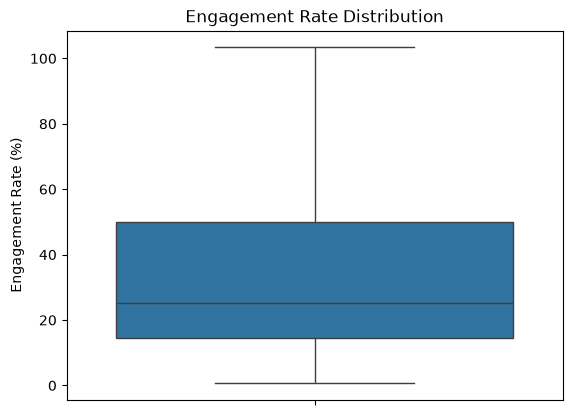

In [29]:
sns.boxplot(data=df_clean, y="engagement_rate", showfliers=False)
plt.ylabel("Engagement Rate (%)")
plt.title("Engagement Rate Distribution")
plt.show()

## Task 6 — Data Visualization
- Matplotlib
- Scatter: likes vs impressions

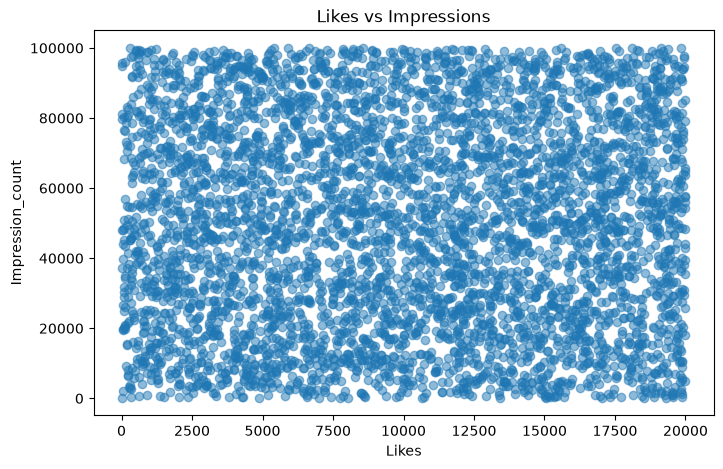

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.scatter(df_clean["likes"], df_clean["impression_count"],alpha=0.5)

plt.xlabel("Likes")
plt.ylabel("Impression_count")
plt.title("Likes vs Impressions")

plt.show()


In [34]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'date_posted-at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='str')

### Line: daily engagement trend

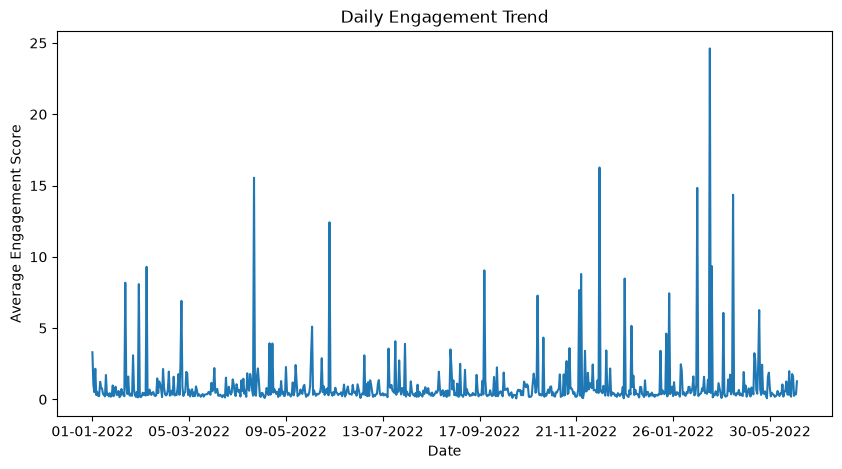

In [36]:
daily_engagement = df_clean.groupby("date_posted-at")["engagement_rate"].mean()

daily_engagement.plot(figsize=(10, 5))

plt.xlabel("Date")
plt.ylabel("Average Engagement Score")
plt.title("Daily Engagement Trend")

plt.show()

## Bar: posts by category

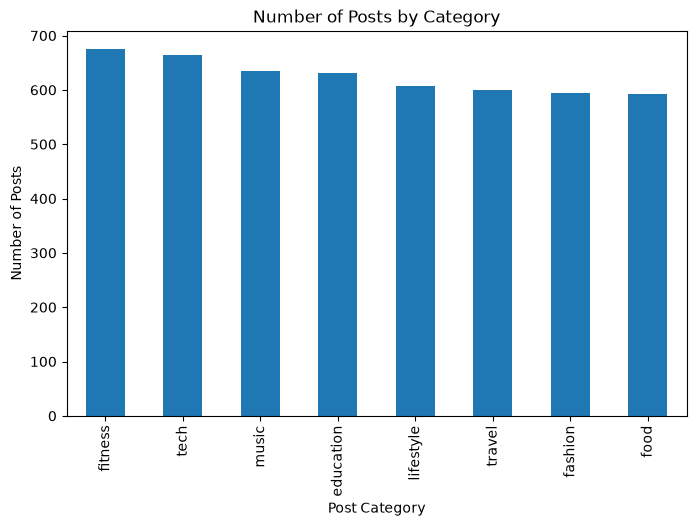

In [37]:
df_clean["post_category"].value_counts().plot(kind="bar",figsize=(8, 5))
    
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.title("Number of Posts by Category")

plt.show()

## Pie: gender distribution

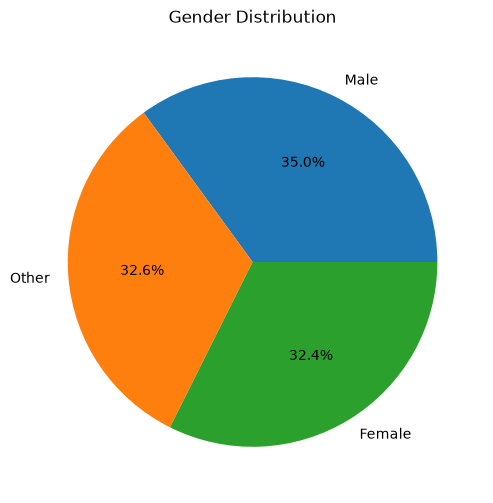

In [38]:
gender_counts = df_clean["gender"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

## Histogram: age

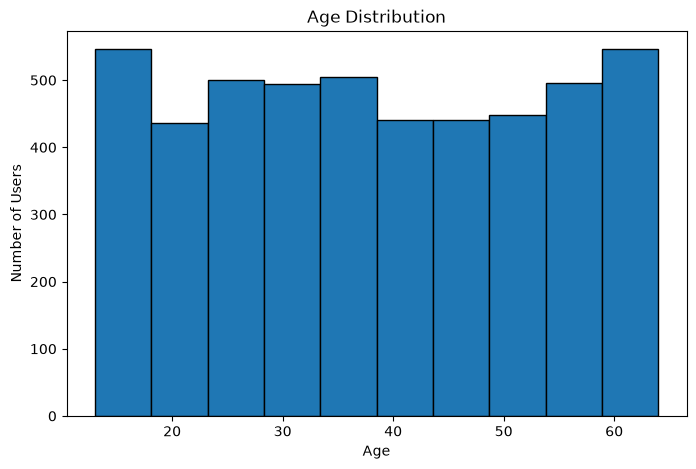

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean["age"], bins=10,edgecolor="black")

plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.title("Age Distribution")

plt.show()

## Box plot: engagement rate

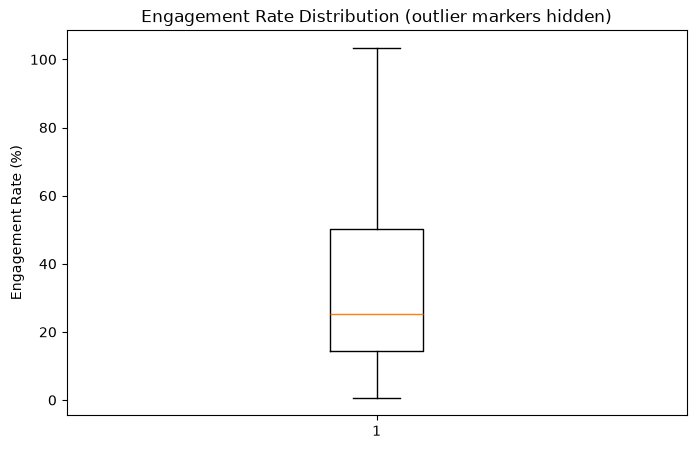

In [54]:
rates = df_clean["engagement_rate_pct"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot(rates, showfliers=False)
plt.ylabel("Engagement Rate (%)")
plt.title("Engagement Rate Distribution (outlier markers hidden)")
plt.show()

## Seaborn
○ Count plot: post type

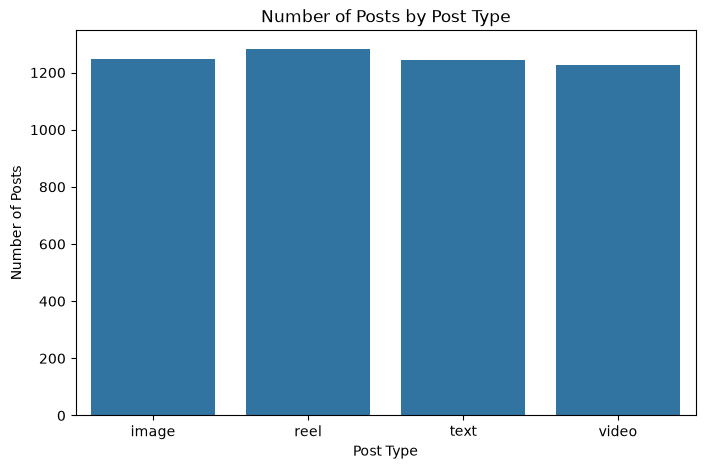

In [55]:
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="post_type")

plt.xlabel("Post Type")
plt.ylabel("Number of Posts")
plt.title("Number of Posts by Post Type")

plt.show()

## Seaborn Bar Plot: Average Likes by Category

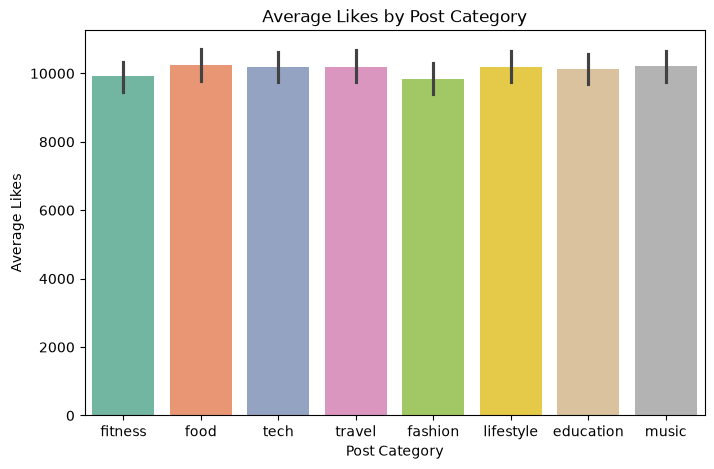

In [56]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df_clean, x="post_category", y="likes", estimator="mean", palette="Set2")

plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.title("Average Likes by Post Category")

plt.show()

## Violin: followers vs sentiment

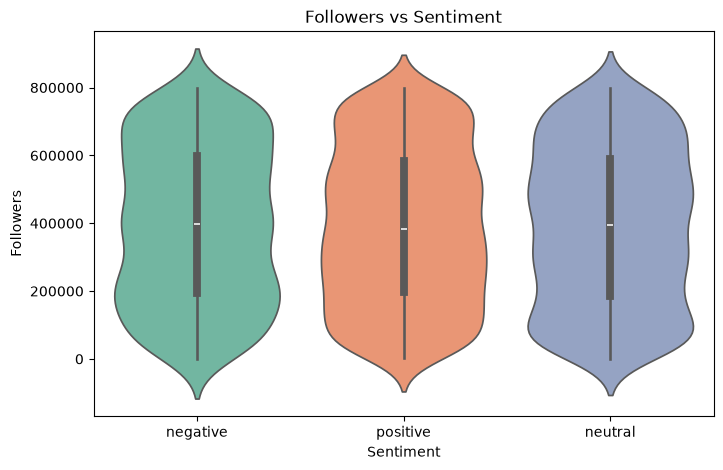

In [57]:
plt.figure(figsize=(8, 5))

sns.violinplot(data=df_clean, x="sentiment", y="follower_count",palette="Set2")

plt.xlabel("Sentiment")
plt.ylabel("Followers")
plt.title("Followers vs Sentiment")

plt.show()

## Pair plot: numeric features

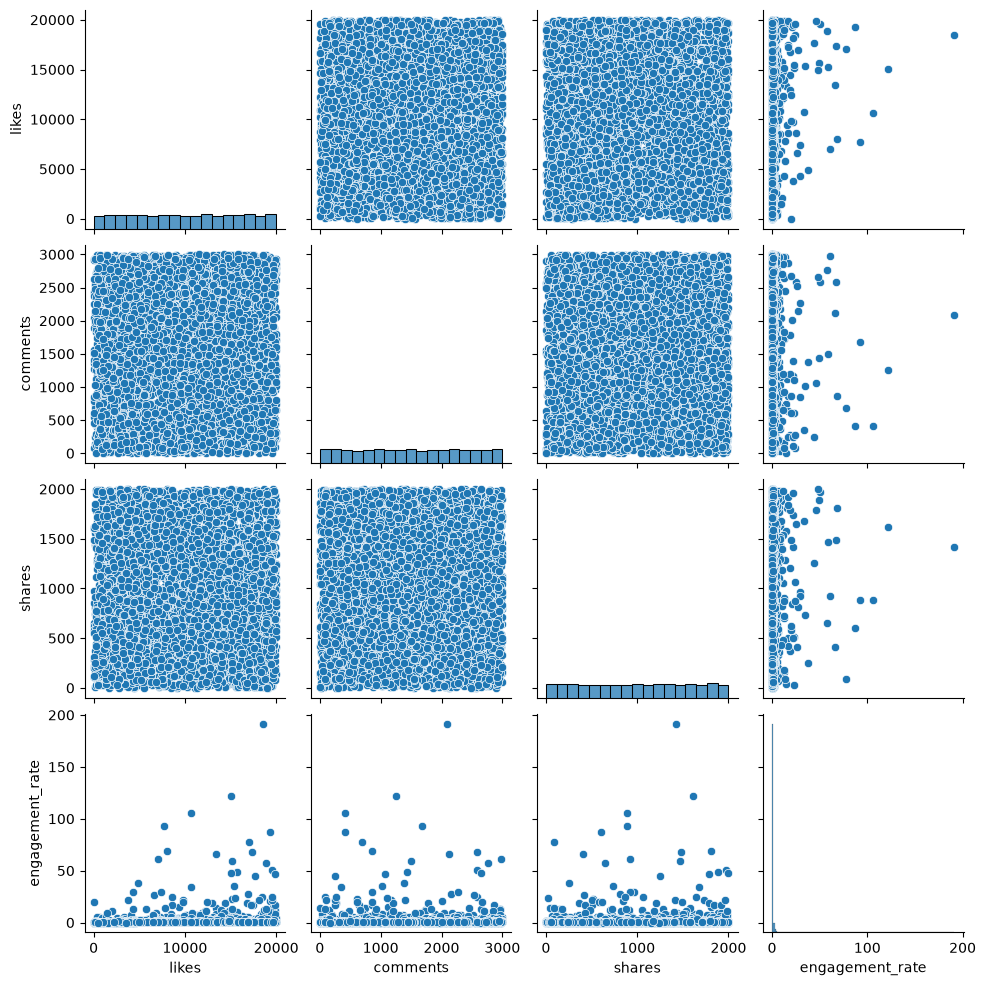

In [58]:
sns.pairplot(
    df_clean[["likes", "comments", "shares", "engagement_rate"]].dropna()
)

plt.show()

## Heatmap: correlation matrix

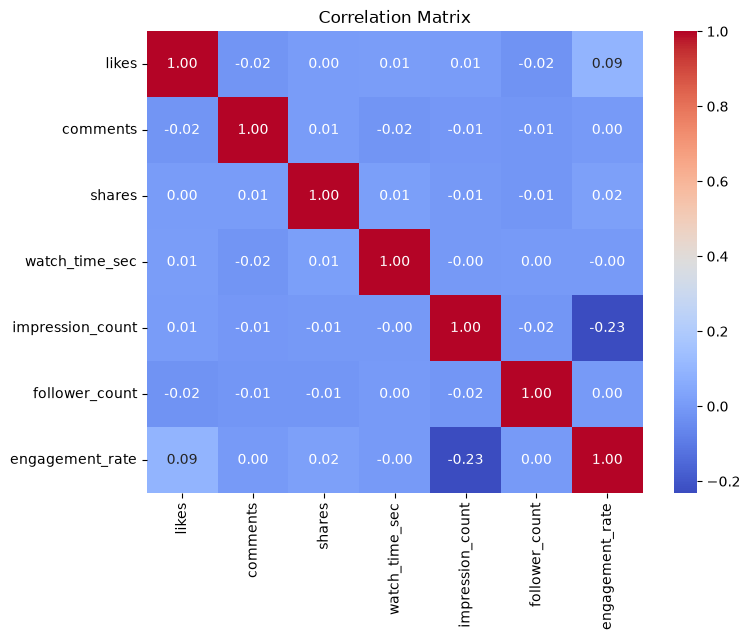

In [59]:
plt.figure(figsize=(8, 6))

corr = df_clean[
    ["likes", "comments", "shares", "watch_time_sec",
     "impression_count", "follower_count", "engagement_rate"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

##  Swarm plot: engagement vs device

In [ ]:
plt.figure(figsize=(10, 5))

sns.swarmplot( data=df_clean, x="device_type",y="engagement_rate",size=2)

plt.xlabel("Device Type")
plt.ylabel("Engagement Rate")
plt.title("Engagement Rate by Device Type")

plt.show()


In [ ]:
!pip install plotly
import plotly.express as px
import plotly.graph_objects as go

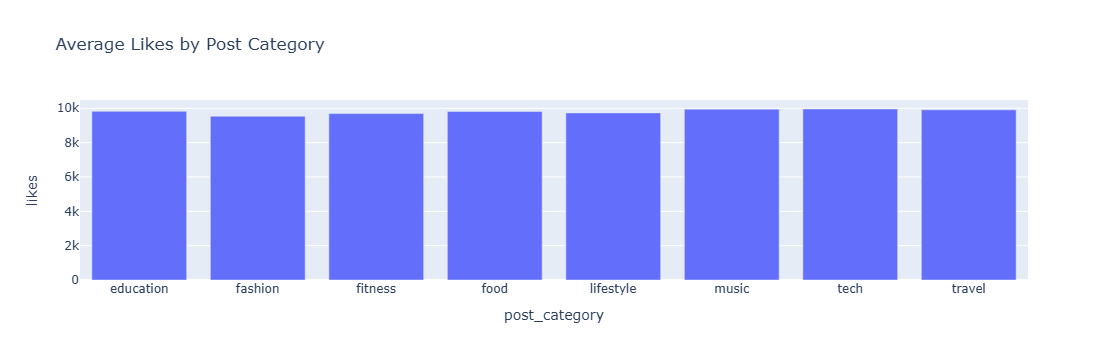

In [88]:
avg_likes = df_clean.groupby("post_category", as_index=False)["likes"].mean()

fig = px.bar(
    avg_likes,
    x="post_category",
    y="likes",
    title="Average Likes by Post Category"
)

fig.show()

In [87]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'date_posted-at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='str')

# Plotly (Interactive)
○ Interactive line chart/bar chart/bubble/scatter chart

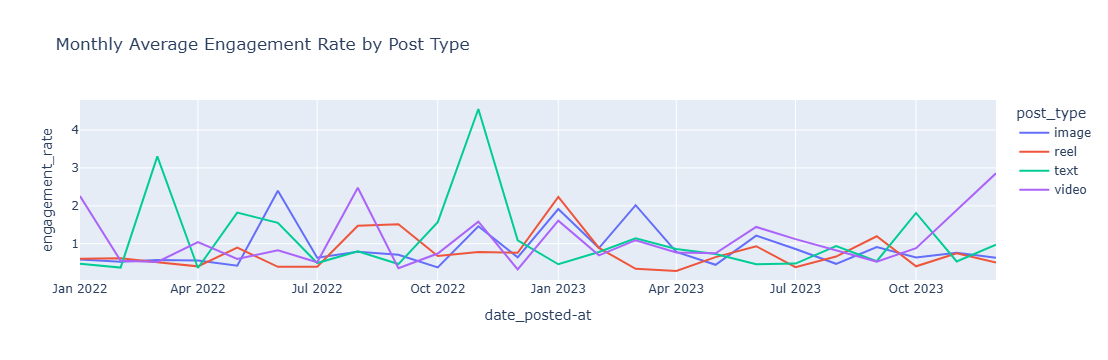

In [83]:
import plotly.express as px
df_monthly = df_clean.groupby([df_clean['date_posted-at'].dt.to_period('M'), 'post_type'])['engagement_rate'].mean().reset_index()
df_monthly['date_posted-at'] = df_monthly['date_posted-at'].dt.to_timestamp()

import plotly.express as px
fig = px.line(df_monthly,
              x='date_posted-at',
              y='engagement_rate',
              color='post_type',
              title='Monthly Average Engagement Rate by Post Type')
fig.show()


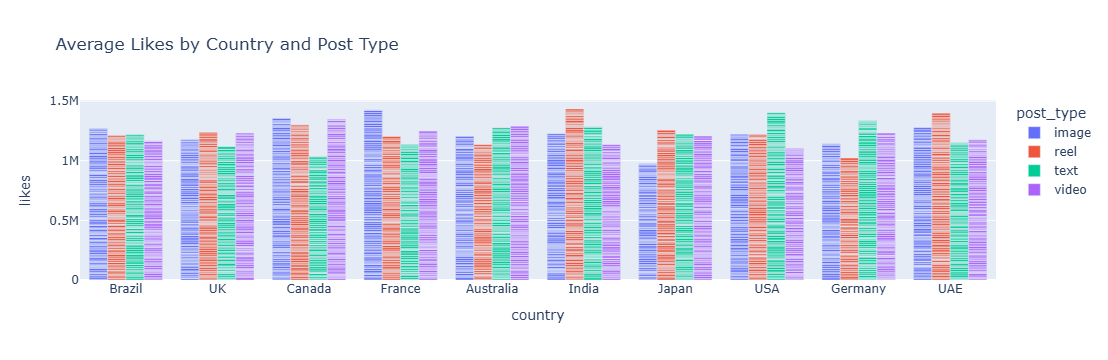

In [84]:
fig = px.bar(df_clean,
             x='country',
             y='likes',
             color='post_type',
             barmode='group',
             title='Average Likes by Country and Post Type')
fig.show()


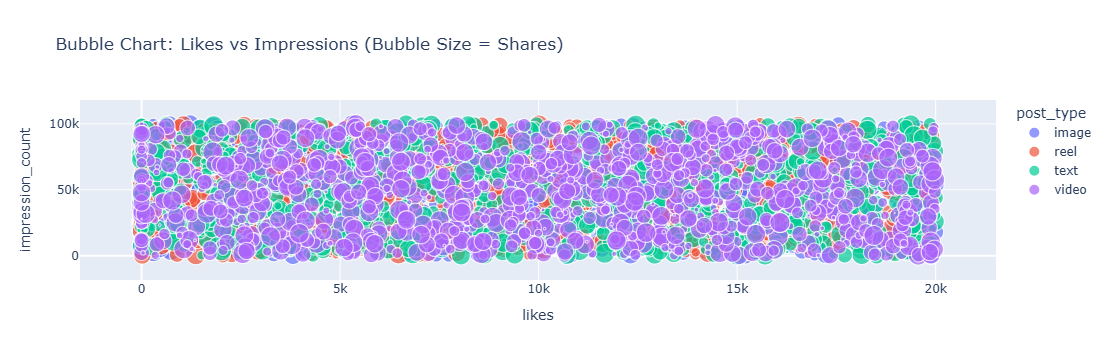

In [85]:
import plotly.express as px
import plotly.io as pio

fig = px.scatter(df_clean,
                 x='likes',
                 y='impression_count',
                 size='shares',          # bubble size = shares
                 color='post_type',
                 hover_name='country',
                 title='Bubble Chart: Likes vs Impressions (Bubble Size = Shares)')
fig.show()


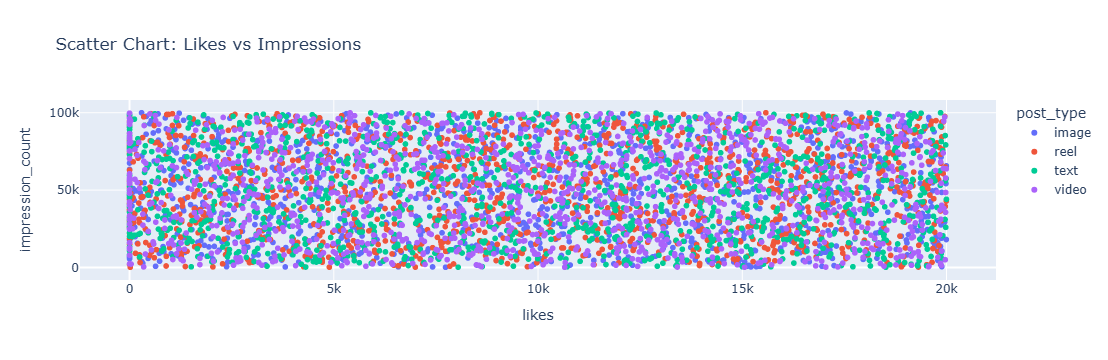

In [86]:
fig = px.scatter(df_clean,
                 x='likes',
                 y='impression_count',
                 color='post_type',
                 title='Scatter Chart: Likes vs Impressions')
fig.show()



# Finding insights ()

In [81]:
#1).Which post types have the highest engagement?
avg_engagement = (
    df_clean.groupby("post_type")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Engagement Rate by Post Type:")
print(avg_engagement)

Average Engagement Rate by Post Type:
post_type
video    1.122365
text     1.064549
image    0.895646
reel     0.783047
Name: engagement_rate, dtype: float64


In [80]:
print("Top Post Types with Highest Engagement:")
print(avg_engagement.head(5))

Top Post Types with Highest Engagement:
country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
Name: engagement_rate, dtype: float64


In [78]:
#2).Best-performing content category?
avg_category = df_clean.groupby("post_category")["likes"].mean()

avg_category

post_category
education    9822.201268
fashion      9537.129630
fitness      9690.035556
food         9816.531197
lifestyle    9731.056013
music        9951.122835
tech         9958.824060
travel       9909.981667
Name: likes, dtype: float64

In [79]:
best_category = avg_category.idxmax()
best_likes = avg_category.max()

print("Best-performing content category:", best_category)
print("Average likes:", best_likes)

Best-performing content category: tech
Average likes: 9958.824060150377


In [ ]:
3).Which countries have the highest average engagement rate?

In [76]:
avg_engagement = (
    df_clean.groupby("country")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 5 Countries with Highest Average Engagement Rate:")
print(avg_engagement.head(5))

Top 5 Countries with Highest Average Engagement Rate:
country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
Name: engagement_rate, dtype: float64


In [75]:
# 4). How age affects engagement?
age_engagement = (
    df_clean.groupby("age")["engagement_rate"]
    .mean()
    .reset_index()
)

print(age_engagement)

    age  engagement_rate
0    13         0.455583
1    14         1.003067
2    15         0.714170
3    16         1.226848
4    17         0.858763
5    18         0.888391
6    19         0.676687
7    20         0.515541
8    21         0.452752
9    22         0.586786
10   23         0.922448
11   24         2.897327
12   25         1.041681
13   26         0.501467
14   27         0.775328
15   28         0.385081
16   29         1.110432
17   30         1.270129
18   31         0.440684
19   32         0.581710
20   33         1.277557
21   34         0.557236
22   35         1.521596
23   36         0.609569
24   37         0.494109
25   38         1.035114
26   39         0.436184
27   40         0.930504
28   41         1.540070
29   42         1.350772
30   43         0.566439
31   44         0.795102
32   45         0.513521
33   46         0.663994
34   47         1.402015
35   48         1.675878
36   49         0.999235
37   50         1.552627
38   51         2.397295


In [74]:
#5).Performance difference for verified accounts?
verified_performance = (
    df_clean.groupby("is_verified")["engagement_rate"]
    .mean()
)

print("Average Engagement Rate by Verification Status:")
print(verified_performance)

Average Engagement Rate by Verification Status:
is_verified
False    0.954744
True     1.054250
Name: engagement_rate, dtype: float64


In [ ]:
#6).Best time of day for impressions

In [73]:
df_clean["hour"] = df_clean["date_posted-at"].dt.hour
print(df_clean["date_posted-at"].head())

0   2022-12-17
1   2023-06-02
2   2023-05-07
3   2023-02-12
4   2023-05-23
Name: date_posted-at, dtype: datetime64[us]


In [72]:
print(df_clean.columns.tolist())


['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'date_posted-at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count', 'engagement_score']


In [71]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  date_posted-at    5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 non-null   b

In [70]:
# 6).Best time of day for impressions
df_clean.groupby('post_type')['watch_time_sec'].mean().sort_values(ascending=False)


post_type
reel     4135.727202
video    4026.673469
text     4010.873092
image    3881.448276
Name: watch_time_sec, dtype: float64

In [69]:
# 7). Device type impact on watch time
df_clean.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False)


device_type
mobile     4087.830760
tablet     3979.736429
desktop    3974.792521
Name: watch_time_sec, dtype: float64

In [68]:
#8).Which sentiment performs best
avg_sentiment = (
    df_clean.groupby("sentiment")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Engagement Rate by Sentiment:")
print(avg_sentiment)

Average Engagement Rate by Sentiment:
sentiment
Negative    1.038486
Neutral     0.991170
Positive    0.919744
Name: engagement_rate, dtype: float64
